In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys, os
sys.path.append(os.path.abspath(".."))
from config import ENGINE
warnings.filterwarnings("ignore")
engine = ENGINE

In [2]:
sns.set_style("whitegrid")

In [3]:
df = pd.read_sql("SELECT * FROM car_data_cleaned", engine)
df.head()

,index,name,price,origin,mileage,brand,status,year,fuel_type,body_type,age
0,0,Mazda 3 1.5 AT 2015,535000000,Other,1.0,Mazda,Xe cũ,2015,xăng,Hatchback,10
1,1,Transit limo 10 chỗ siêu lướt chỉ 3000km,1150000000,Trong nước,3000.0,Ford,Xe cũ,2024,dầu,Xe tải,1
2,3,Mitsubishi Pajero Sport 2015 D 4x2 MT - 95000 km,335000000,Nhập khẩu,95000.0,Mitsubishi,Xe cũ,2015,dầu,Crossover,10
3,4,Toyota Vios 2014 1.5G - 43000 km siêu cọp,315000000,Trong nước,43000.0,Toyota,Xe cũ,2014,xăng,Sedan,11
4,5,Mercesdes GLC300 AMG,1188000000,Other,98000.0,Mercedes,Xe cũ,2019,xăng,Crossover,6


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11194 entries, 0 to 11193
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   index      11194 non-null  int64  
 1   name       11194 non-null  object 
 2   price      11194 non-null  int64  
 3   origin     11194 non-null  object 
 4   mileage    11194 non-null  float64
 5   brand      11194 non-null  object 
 6   status     11194 non-null  object 
 7   year       11194 non-null  int64  
 8   fuel_type  11194 non-null  object 
 9   body_type  11194 non-null  object 
 10  age        11194 non-null  int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 962.1+ KB


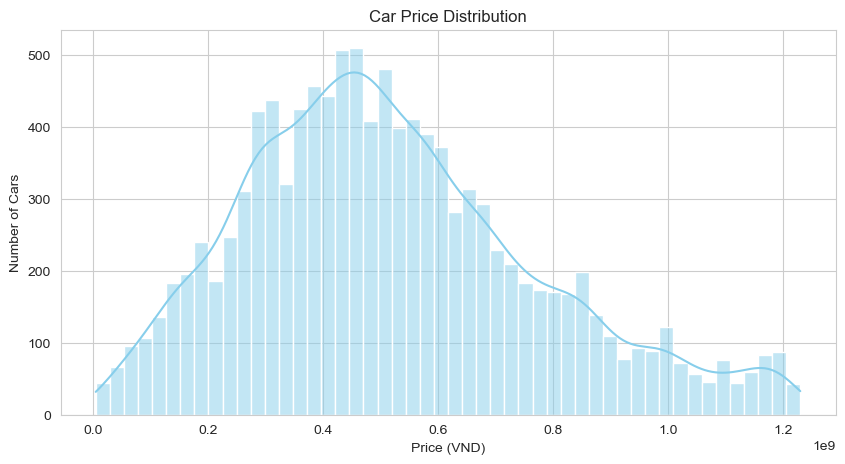

In [5]:
plt.figure(figsize=(10,5))
sns.histplot(df["price"], bins=50, kde=True, color="skyblue")
plt.title("Car Price Distribution")
plt.xlabel("Price (VND)")
plt.ylabel("Number of Cars")
plt.show()

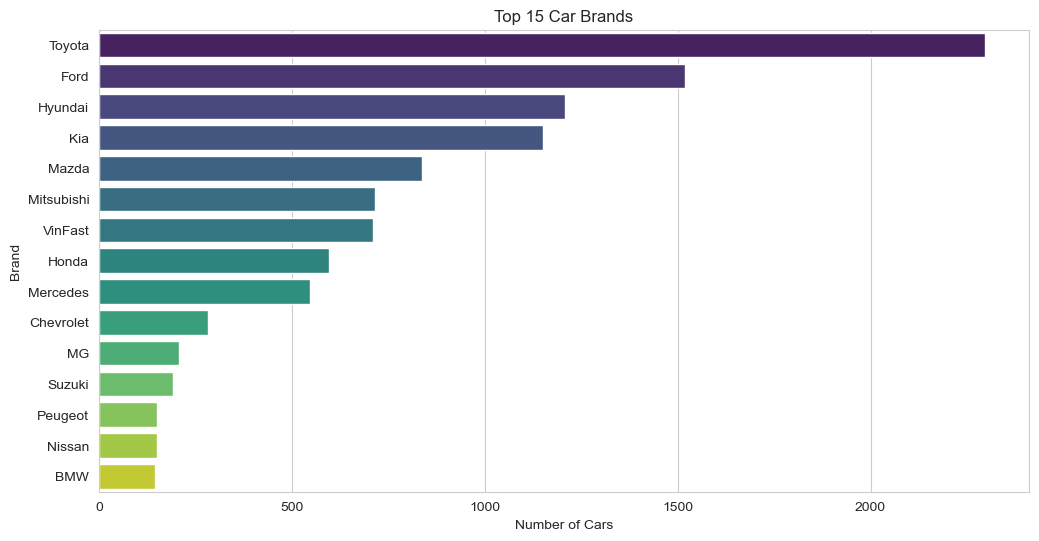

In [6]:
plt.figure(figsize=(12,6))
top_brands = df["brand"].value_counts().head(15)
sns.barplot(x=top_brands.values, y=top_brands.index, palette="viridis")
plt.title("Top 15 Car Brands")
plt.xlabel("Number of Cars")
plt.ylabel("Brand")
plt.show()

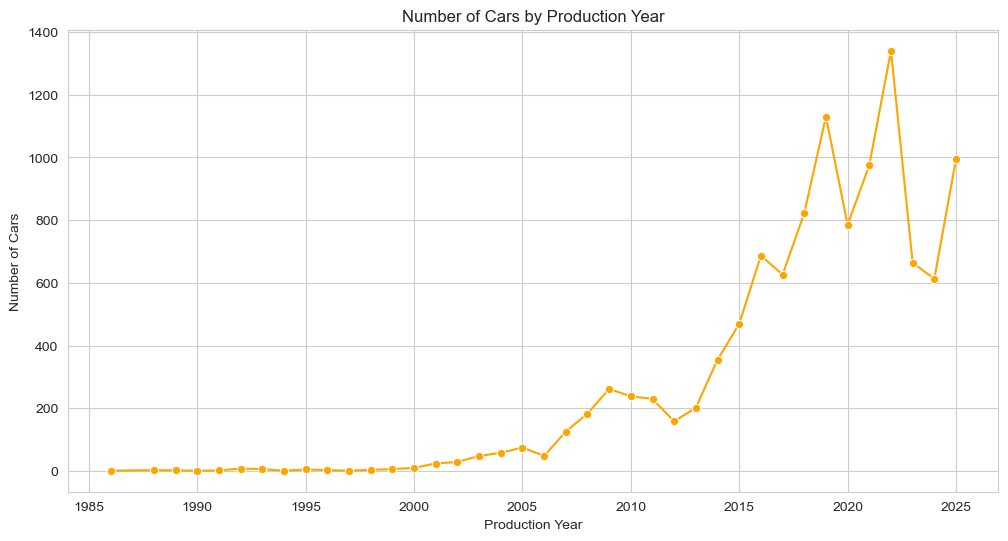

In [7]:
plt.figure(figsize=(12,6))
year_counts = df["year"].value_counts().sort_index()
sns.lineplot(x=year_counts.index, y=year_counts.values, marker="o", color="orange")
plt.title("Number of Cars by Production Year")
plt.xlabel("Production Year")
plt.ylabel("Number of Cars")
plt.show()

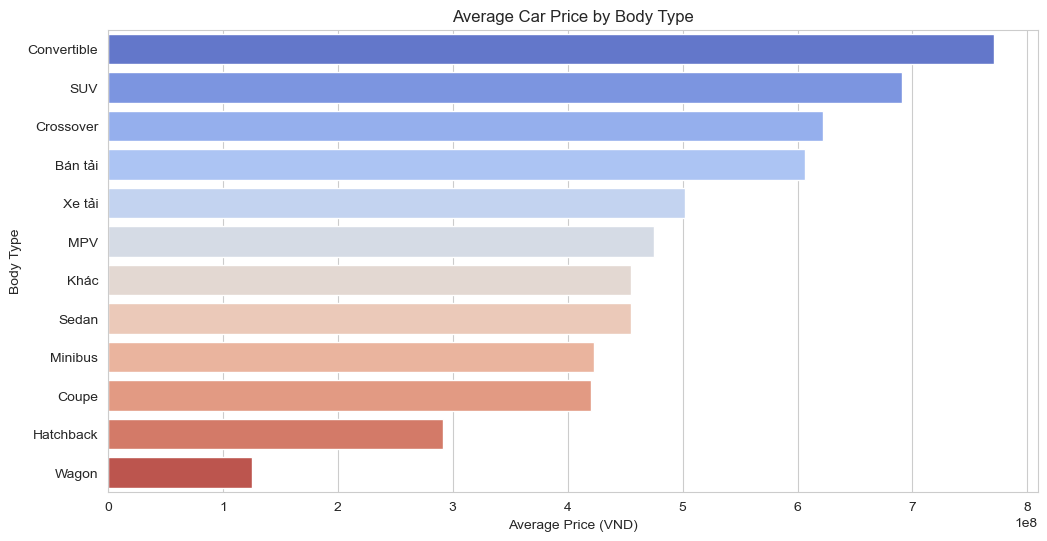

In [8]:
plt.figure(figsize=(12,6))
body_price = df.groupby("body_type")["price"].mean().sort_values(ascending=False)
sns.barplot(x=body_price.values, y=body_price.index, palette="coolwarm")
plt.title("Average Car Price by Body Type")
plt.xlabel("Average Price (VND)")
plt.ylabel("Body Type")
plt.show()

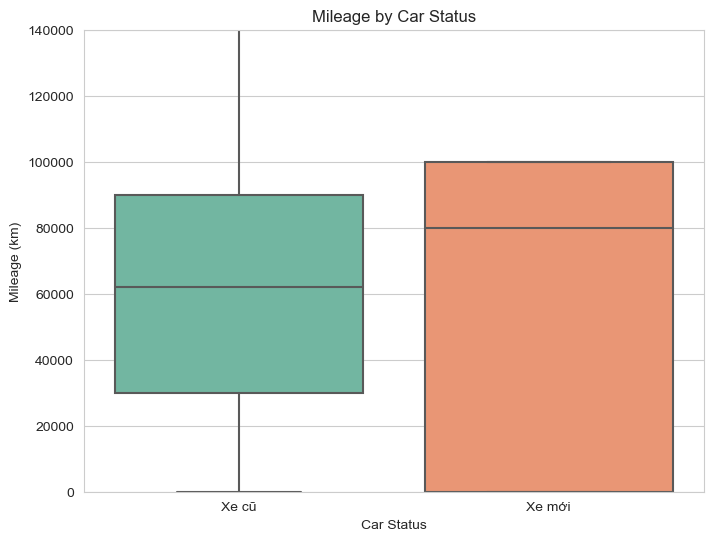

In [9]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="status", y="mileage", palette="Set2")
plt.title("Mileage by Car Status")
plt.xlabel("Car Status")
plt.ylabel("Mileage (km)")
plt.ylim(0, df["mileage"].quantile(0.95))
plt.show()

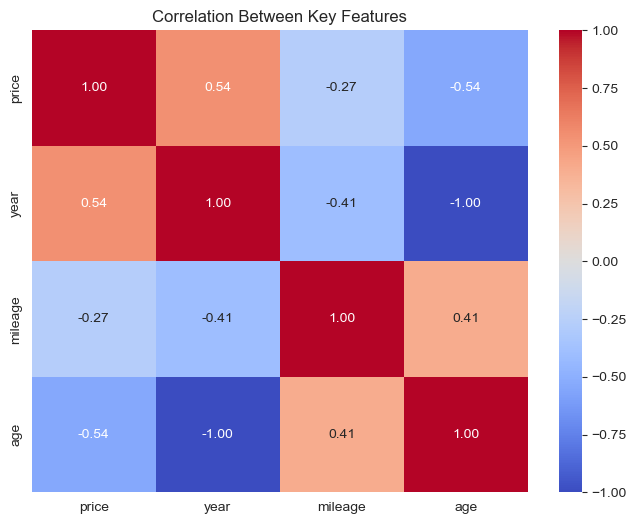

In [10]:
plt.figure(figsize=(8,6))
corr = df[["price", "year", "mileage", "age"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Between Key Features")
plt.show()


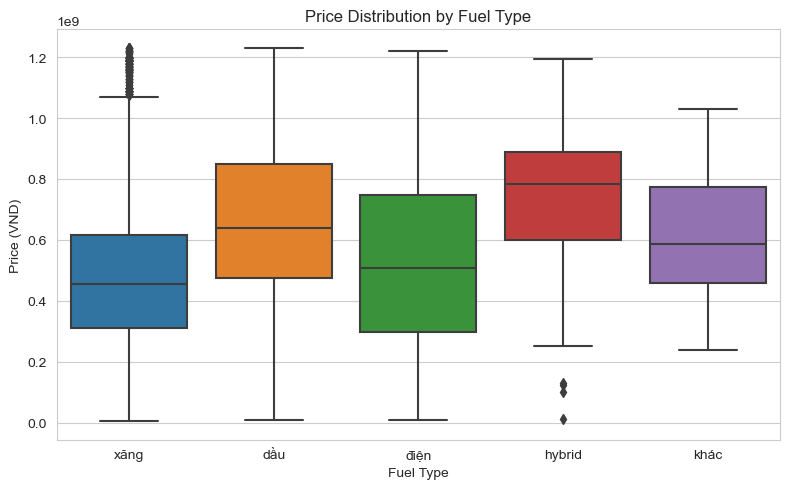

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='fuel_type', y='price')
plt.title('Price Distribution by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Price (VND)')
plt.tight_layout()
plt.show()